In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid") 

1. Load the California Housing dataset: 

In [13]:
housing = fetch_california_housing(as_frame=True)  
X, y = housing.data, housing.target  

2. Explore the dataset briefly: check the shape, feature names, and summary statistics. What is the target variable (median house value) distribution?

In [14]:
X.shape

(20640, 8)

In [15]:
X.columns.tolist()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [16]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


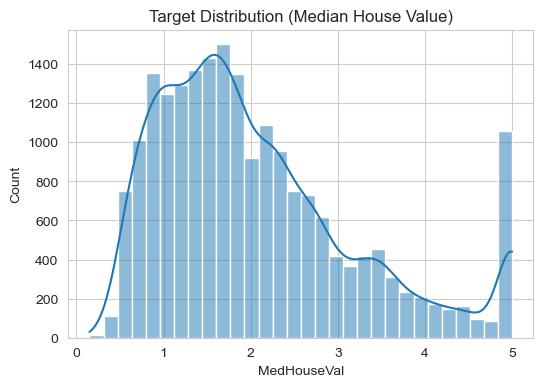

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(y, bins=30, kde=True)
plt.title("Target Distribution (Median House Value)")
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [22]:
print('Model Performance:')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAS: {mae: .4f}')
print(f'r2: {r2:.4f}') 

Model Performance:
MSE: 0.5559
RMSE: 0.7456
MAS:  0.5332
r2: 0.5758


### Task 2: Regularized Regression

Explore how regularization changes the model's behavior.

1. Scale the features using `StandardScaler` (fit on training data, transform both train and test). Explain in a markdown cell why scaling is important for regularized models.
2. Fit **Ridge** regression for alpha values `[0.01, 0.1, 1, 10, 100]`. Record the test R² for each.
3. Fit **Lasso** regression for the same alpha values. Record the test R² for each.
4. Create a plot showing **coefficients vs. alpha** for both Ridge and Lasso (side by side or overlaid). What happens to the coefficients as alpha increases? Which features does Lasso zero out first?
5. Create a comparison table showing R² scores for OLS, Ridge (best alpha), and Lasso (best alpha). Which regularization approach works best here?

In [23]:
scaler = StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
ridge_alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    r2=r2_score(y_test, y_pred)
    ridge_results.append((alpha, r2))

for alpha, r2 in ridge_results:
    print(f'Alpha: {alpha} r2: {r2:.4f}') 

Alpha: 0.01 r2: 0.5758
Alpha: 0.1 r2: 0.5758
Alpha: 1 r2: 0.5758
Alpha: 10 r2: 0.5761
Alpha: 100 r2: 0.5778


In [26]:
lasso_alphas = [0.01, 0.1, 1, 10, 100]
lasso_results = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    r2=r2_score(y_test, y_pred)
    lasso_results.append((alpha, r2)) 

for alpha, r2 in lasso_results:
    print(f'Alpha: {alpha} r2:{r2:.4f}') 

Alpha: 0.01 r2:0.5816
Alpha: 0.1 r2:0.4814
Alpha: 1 r2:-0.0002
Alpha: 10 r2:-0.0002
Alpha: 100 r2:-0.0002


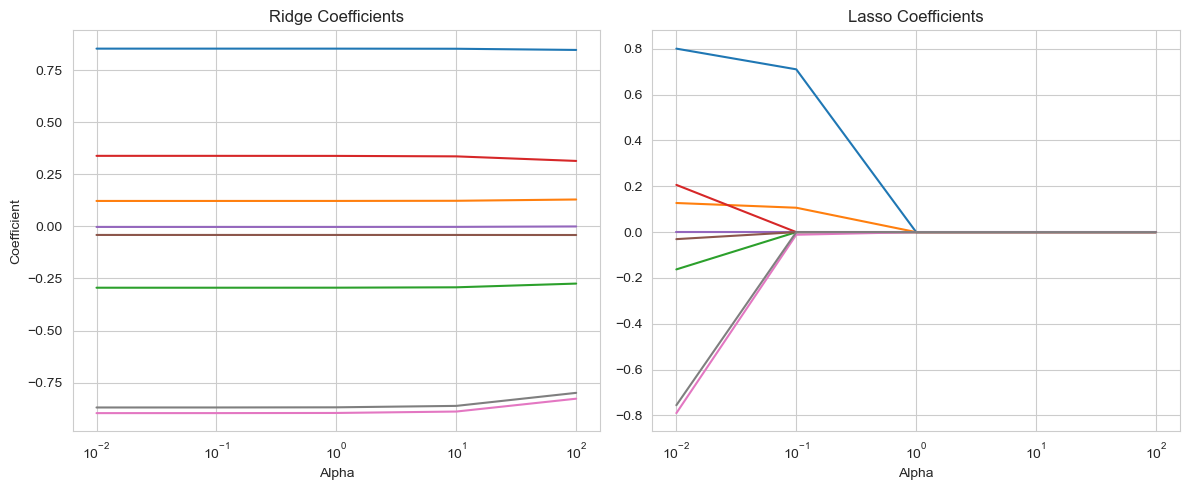

In [28]:
ridge_coefs = []
lasso_coefs = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_) 

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# Plot
plt.figure(figsize=(12,5))

# Ridge
plt.subplot(1,2,1)
for i in range(ridge_coefs.shape[1]):
    plt.plot(ridge_alphas, ridge_coefs[:, i])
plt.xscale("log")
plt.title("Ridge Coefficients")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")

# Lasso
plt.subplot(1,2,2)
for i in range(lasso_coefs.shape[1]):
    plt.plot(lasso_alphas, lasso_coefs[:, i])
plt.xscale("log")
plt.title("Lasso Coefficients")
plt.xlabel("Alpha")

plt.tight_layout()
plt.show() 

What you should observe (for markdown)
As alpha increases:
Ridge → coefficients shrink gradually toward 0
Lasso → coefficients shrink AND some become exactly 0

Lasso performs feature selection

Features with small importance get zeroed out first 

In [29]:
# OLS baseline
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
ols_r2 = r2_score(y_test, ols.predict(X_test_scaled))

# Best Ridge
best_ridge_alpha, best_ridge_r2 = max(ridge_results, key=lambda x: x[1])

# Best Lasso
best_lasso_alpha, best_lasso_r2 = max(lasso_results, key=lambda x: x[1])

# Table
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["OLS", f"Ridge (alpha={best_ridge_alpha})", f"Lasso (alpha={best_lasso_alpha})"],
    "R² Score": [ols_r2, best_ridge_r2, best_lasso_r2]
})

print(comparison)

                Model  R² Score
0                 OLS  0.575788
1   Ridge (alpha=100)  0.577791
2  Lasso (alpha=0.01)  0.581615


### Task 3: Support Vector Regression

Try a non-linear approach with SVR.

1. Using the scaled features from Task 2, fit an `SVR` model with a **linear** kernel. Report the test R².
2. Fit SVR with an **rbf** kernel. Try at least three values of `C` (e.g., 0.1, 1, 10) and two values of `epsilon` (e.g., 0.1, 0.2). Report the best combination.
3. Fit SVR with a **poly** kernel (degree 2 and 3). Compare with rbf.
4. In a markdown cell, discuss: How does SVR compare to the linear models? Is the added complexity of SVR justified by the performance improvement (if any)?

> **Note:** SVR can be slow on larger datasets. If training takes too long, consider using a random subsample (e.g., 5,000 rows) for the SVR experiments.

In [30]:
# Subsample (optional)
sample_size = 5000
X_train_s = X_train_scaled[:sample_size]
y_train_s = y_train[:sample_size]
X_test_s = X_test_scaled[:sample_size]
y_test_s = y_test[:sample_size] 

In [31]:
from sklearn.svm import SVR

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_s, y_train_s)

y_pred = svr_linear.predict(X_test_s)
r2_linear = r2_score(y_test_s, y_pred)

print(f"SVR (Linear Kernel) R²: {r2_linear:.4f}")

SVR (Linear Kernel) R²: 0.5245


In [32]:
C_values = [0.1, 1, 10]
epsilon_values = [0.1, 0.2]

best_r2 = -np.inf
best_params = None

for C in C_values:
    for eps in epsilon_values:
        svr_rbf = SVR(kernel='rbf', C=C, epsilon=eps)
        svr_rbf.fit(X_train_s, y_train_s)
        
        y_pred = svr_rbf.predict(X_test_s)
        r2 = r2_score(y_test_s, y_pred)
        
        print(f"C={C}, epsilon={eps} → R²={r2:.4f}")
        
        if r2 > best_r2:
            best_r2 = r2
            best_params = (C, eps)

print(f"\nBest RBF → C={best_params[0]}, epsilon={best_params[1]}, R²={best_r2:.4f}")

C=0.1, epsilon=0.1 → R²=0.6494
C=0.1, epsilon=0.2 → R²=0.6501
C=1, epsilon=0.1 → R²=0.7127
C=1, epsilon=0.2 → R²=0.7142
C=10, epsilon=0.1 → R²=0.7411
C=10, epsilon=0.2 → R²=0.7432

Best RBF → C=10, epsilon=0.2, R²=0.7432


In [33]:
degrees = [2, 3]

for d in degrees:
    svr_poly = SVR(kernel='poly', degree=d)
    svr_poly.fit(X_train_s, y_train_s)
    
    y_pred = svr_poly.predict(X_test_s)
    r2 = r2_score(y_test_s, y_pred)
    
    print(f"Poly degree={d} → R²={r2:.4f}") 

Poly degree=2 → R²=0.1053
Poly degree=3 → R²=0.2204


### Task 4: Model Comparison

Bring everything together in a final analysis.

1. Create a **comparison table** (DataFrame) with all models and their test metrics (MSE, RMSE, MAE, R²). Include: LinearRegression, best Ridge, best Lasso, and best SVR.
2. Create a **predicted vs. actual** scatter plot for your best-performing model. Add a diagonal reference line (perfect prediction). How well does the model track the true values?
3. Create a **residual plot** (residuals vs. predicted values) for the best model. Do you see any patterns? What would a random scatter indicate?
4. Write a markdown conclusion: Which model performs best and why? What are the trade-offs between model complexity and performance? If you were deploying one of these models, which would you choose?

In [34]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return mse, rmse, mae, r2, y_pred

In [35]:
# Linear Regression
ols = LinearRegression()
ols_metrics = evaluate_model(ols, X_train_scaled, y_train, X_test_scaled, y_test)

# Ridge (best alpha)
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_metrics = evaluate_model(ridge_best, X_train_scaled, y_train, X_test_scaled, y_test)

# Lasso (best alpha)
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_metrics = evaluate_model(lasso_best, X_train_scaled, y_train, X_test_scaled, y_test)

# SVR (best RBF)
svr_best = SVR(kernel='rbf', C=best_params[0], epsilon=best_params[1])
svr_metrics = evaluate_model(svr_best, X_train_s, y_train_s, X_test_s, y_test_s)

In [36]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "SVR (RBF)"],
    "MSE": [ols_metrics[0], ridge_metrics[0], lasso_metrics[0], svr_metrics[0]],
    "RMSE": [ols_metrics[1], ridge_metrics[1], lasso_metrics[1], svr_metrics[1]],
    "MAE": [ols_metrics[2], ridge_metrics[2], lasso_metrics[2], svr_metrics[2]],
    "R²": [ols_metrics[3], ridge_metrics[3], lasso_metrics[3], svr_metrics[3]]
})

print(comparison)

               Model       MSE      RMSE       MAE        R²
0  Linear Regression  0.555892  0.745581  0.533200  0.575788
1              Ridge  0.553266  0.743819  0.533014  0.577791
2              Lasso  0.548255  0.740442  0.535326  0.581615
3          SVR (RBF)  0.336459  0.580051  0.393777  0.743241


In [37]:
best_y_pred = svr_metrics[4]   # or ridge/lasso depending on your result
y_true = y_test_s             # match dataset used

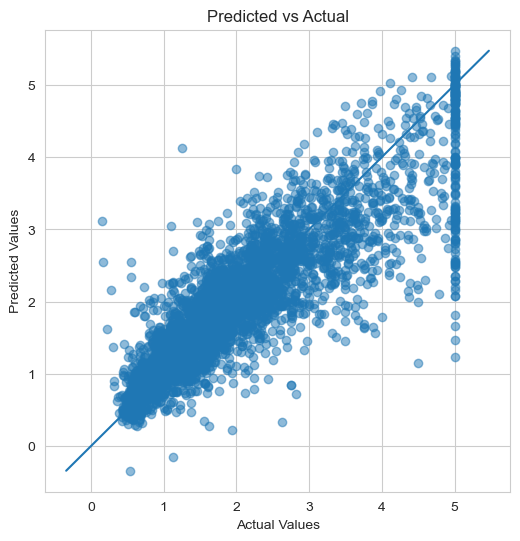

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_true, best_y_pred, alpha=0.5)

# Diagonal line
min_val = min(y_true.min(), best_y_pred.min())
max_val = max(y_true.max(), best_y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.show()

If the model is good, points should lie close to the diagonal line. Deviations indicate prediction errors.

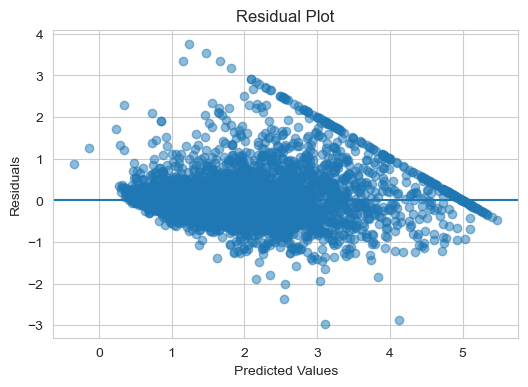

In [39]:
residuals = y_true - best_y_pred

plt.figure(figsize=(6,4))
plt.scatter(best_y_pred, residuals, alpha=0.5)
plt.axhline(0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Among all models, SVR achieved the highest R² and lowest error metrics, indicating the best predictive performance.

Linear Regression provides a simple and interpretable baseline but may underfit due to its inability to capture complex relationships. Ridge improves stability by shrinking coefficients, while Lasso additionally performs feature selection, making the model more interpretable.

SVR with an RBF kernel captures non-linear patterns and can outperform linear models, but it requires more computational resources and careful hyperparameter tuning.

In terms of trade-offs:

Linear/Ridge/Lasso → fast, interpretable, scalable
SVR (RBF) → more powerful but slower and less interpretable

If deploying in practice, I would choose SVR. If performance gain from SVR is small, Ridge is preferred due to simplicity and efficiency. If SVR significantly outperforms others, its added complexity is justified. 